# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a Convolutional Neural Network is used for image classification in order to classify different stages of dementia, very mild, mild, moderate as well as having none (link: https://www.kaggle.com/datasets/ninadaithal/imagesoasis). The data itself was retrieved from the Open Access Series of Imaging Studies (OASIS) (link: https://sites.wustl.edu/oasisbrains/), allowing for the model to be trained on actual imaging scan results of patients with varying levels of dementia. Another model is then trained to classify patients without dementia and those with very mild dementia. This may be better in a practical scenario as it may be more valuable to detect the earliest signs of dementia in order for it to be treated as soon as possible.

# Loading The Data
The library used to create the neural network model is tensorflow. The cell below loads the dataset and splits it into a training and validation set. The images are also kept to a size 180x180 pixels and 128 images are processed at a time before the model updates its weights. 

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

image_size = (180, 180)
batch_size = 128

ds = keras.utils.image_dataset_from_directory(
    "Data",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

total_batches = len(ds)
train_size = int(0.7 * total_batches)
val_size   = int(0.15 * total_batches)

class_names = ds.class_names
num_classes = len(class_names)

#Taking specific percentages of the dataset read in initially based on above calculations
train_ds = ds.take(train_size)
val_ds   = ds.skip(train_size).take(val_size)
test_ds  = ds.skip(train_size + val_size)

Found 86437 files belonging to 4 classes.


# Preprocessing The Data
The data augmented by randomly horizontally flipping the images and slightly rotating them to diversify the data and also avoid overfitting. Autotune allows for the optimal number of image batches to be stored in memory before allowing the model to process them based on the CPU and GPU workload, speeding up processing time but doesn't actually affect the model.

In [2]:
# Data augmentation flips the image horizontally and rotates it so the model can generalise better
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

#Automatically gets optimal batch of images to retrieve based on current CPU and GPU workload, speeding up time to process images, doesn't affect model performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x), y),
    num_parallel_calls=AUTOTUNE
)

#Allows for fetching optimal amount of data before it's actually needed to speed up processing
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Training The Model
The model itself has three convolution layers and two dense layers with the convolutions and one dense layer using a relu function with the final dense layer using softmax. The rescaling layer squashes the rgb values from 0 to 255 to be in between 0 and 1 in order ot standardise the image. The convolution layer start with 16 filters and doubles after pooling layer to reduce the spatial dimensions of the image while keeping essential information. The flatten layer converts the results of the convolution layers into a 1 dimensional vector before the first dense layer receives the inputs from the previous layer and processes it with 128 neurons before the second dense layer outputs the prediction. The model is then compiled.

In [3]:
# Model
model = models.Sequential([
    #Squashes rgb values in image to be between 0 and 1 to standardise the image
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\nasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

# Training The Model And Retrieving Performance
The model is trained over 10 epochs. The history object stores accuracy and loss values for both training and validation after each epoch. The four metrics: accuracy, val_accuracy, loss, val_loss are retrieved and are also plotted.

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 394s 827ms/step - accuracy: 0.7939 - loss: 0.5324 - val_accuracy: 0.8186 - val_loss: 0.4218
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 300s 633ms/step - accuracy: 0.8359 - loss: 0.3892 - val_accuracy: 0.8607 - val_loss: 0.3404
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.8766 - loss: 0.3034 - val_accuracy: 0.8807 - val_loss: 0.3047
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 302s 638ms/step - accuracy: 0.9122 - loss: 0.2237 - val_accuracy: 0.9121 - val_loss: 0.2189
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 304s 641ms/step - accuracy: 0.9355 - loss: 0.1683 - val_accuracy: 0.9336 - val_loss: 0.1588
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 302s 637ms/step - accuracy: 0.9551 - loss: 0.1211 - val_accuracy: 0.9502 - val_loss: 0.1289
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 305s 643ms/step - accuracy: 0.9658 - loss: 0.0929 - val_accuracy: 0.9702 - val_loss: 0.0835
Epoch 8/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 307s 648ms/step - accuracy: 0.9736 - lo

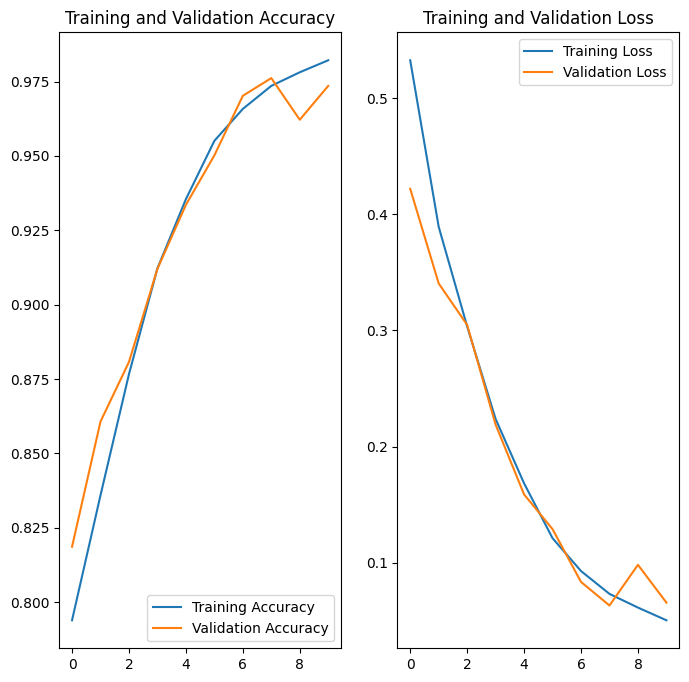

In [4]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [5]:
test_loss, test_accuracy = model.evaluate(test_ds, batch_size=128)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

102/102 ━━━━━━━━━━━━━━━━━━━━ 57s 311ms/step - accuracy: 0.9786 - loss: 0.0565

Test Accuracy: 0.9786
Test Loss:     0.0565


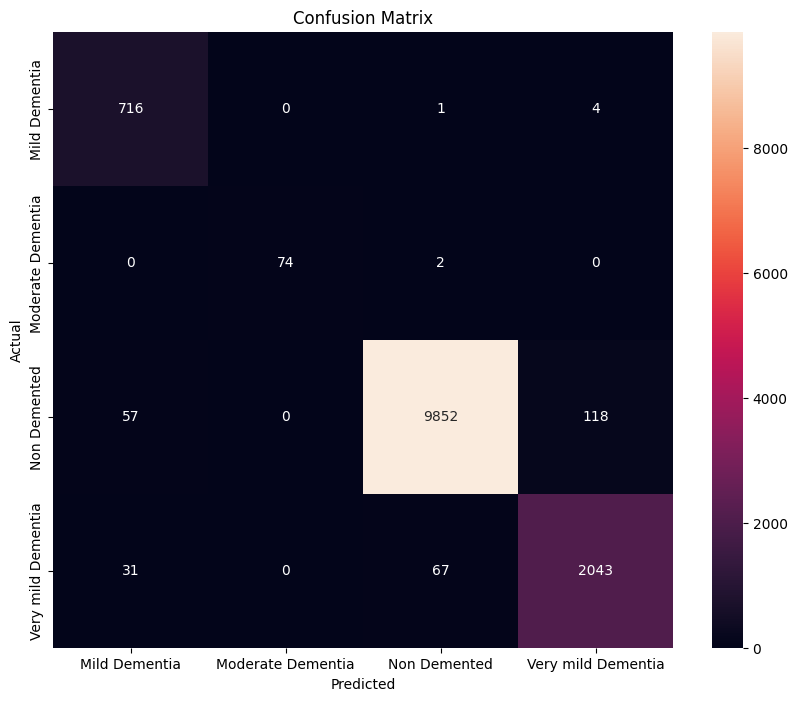

                    precision    recall  f1-score   support

     Mild Dementia       0.89      0.99      0.94       721
 Moderate Dementia       1.00      0.97      0.99        76
      Non Demented       0.99      0.98      0.99     10027
Very mild Dementia       0.94      0.95      0.95      2141

          accuracy                           0.98     12965
         macro avg       0.96      0.98      0.97     12965
      weighted avg       0.98      0.98      0.98     12965



In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Evaluating Results
The models appears to perform very well, with the validation accuracy reaching 0.9862 over 10 epochs as well as the f1 score reaching 0.98 for the testing set. It seems to perform extremely well for classifying non demented and moderate dementia with slightly worse performance in mild and very mild dementia. The very high performance may be due to the fact that many of the classes can have clear differences and may even be verifiable by eye. 

# Classifying Non Demented and Very Mild Dementia
In a real-life scenario in a clinic, it may be more valuable to be able to differentiate between the very early stages of dementia, such as non demented and very mild. The cells below follows a very similar process as the ones previously. The cell below shows the same steps to preprocess the data using data augmentation.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

image_size = (180, 180)
batch_size = 128

ds = keras.utils.image_dataset_from_directory(
    "Data2",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

total_batches = len(ds)
train_size = int(0.7 * total_batches)
val_size   = int(0.15 * total_batches)

class_names = ds.class_names
num_classes = len(class_names)

#Taking specific percentages of the dataset read in initially based on above calculations
train_ds = ds.take(train_size)
val_ds   = ds.skip(train_size).take(val_size)
test_ds  = ds.skip(train_size + val_size)

# Data augmentation flips the image horizontally and rotates it so the model can generalise better
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

Found 80947 files belonging to 2 classes.


# Training The Model
While the same preprocessing steps have been taken, the main difference when setting up the model is that a dropout layer has been added to further reduce overfitting

In [2]:
# Automatically gets optimal batch of images to retrieve based on current CPU and GPU workload
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x), y),
    num_parallel_calls=AUTOTUNE
)

# Allows for fetching optimal amount of data before it's actually needed to speed up processing
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# Model
model = models.Sequential([
    # Squashes RGB values to between 0 and 1 to standardise the image
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    
    layers.MaxPooling2D(),
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


C:\Users\nasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,988,898 (15.22 MB)

 Trainable params: 3,988,898 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 430s 961ms/step - accuracy: 0.8361 - loss: 0.3682 - val_accuracy: 0.8101 - val_loss: 0.3622
Epoch 2/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 279s 629ms/step - accuracy: 0.8646 - loss: 0.2833 - val_accuracy: 0.8718 - val_loss: 0.2781
Epoch 3/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 279s 628ms/step - accuracy: 0.8882 - loss: 0.2366 - val_accuracy: 0.8946 - val_loss: 0.2252
Epoch 4/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 280s 630ms/step - accuracy: 0.9100 - loss: 0.1973 - val_accuracy: 0.9136 - val_loss: 0.1844
Epoch 5/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 812s 2s/step - accuracy: 0.9260 - loss: 0.1678 - val_accuracy: 0.9422 - val_loss: 0.1343
Epoch 6/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 279s 629ms/step - accuracy: 0.9420 - loss: 0.1389 - val_accuracy: 0.9575 - val_loss: 0.1066
Epoch 7/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 282s 634ms/step - accuracy: 0.9505 - loss: 0.1197 - val_accuracy: 0.9673 - val_loss: 0.0935
Epoch 8/10
443/443 ━━━━━━━━━━━━━━━━━━━━ 1062s 2s/step - accuracy: 0.9572 - loss

# Evaluating The Model
Similarly to the previous result, the model has performed very well, with a validation accuracy reaching 0.9758 and an F1 score of 0.93 and 0.99 for the very mild dementia and non demented features respectively. The model was also capable of achieving a perfect precision metric for non demented patients and the recall of 0.96 shows the model rarely gets a false negative for non-demented patients The 0.98 recall for the very mild dementia class shows that the model can catch nearly all actual cases of dementia however the 0.84 precision shows that it may be prone to returning false positives. 

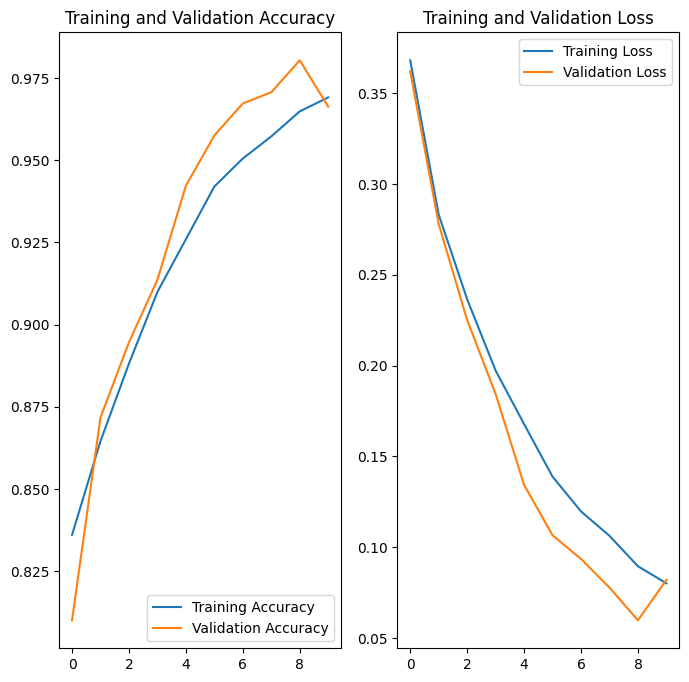

96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 440ms/step - accuracy: 0.9650 - loss: 0.0875

Test Accuracy: 0.9650
Test Loss:     0.0875


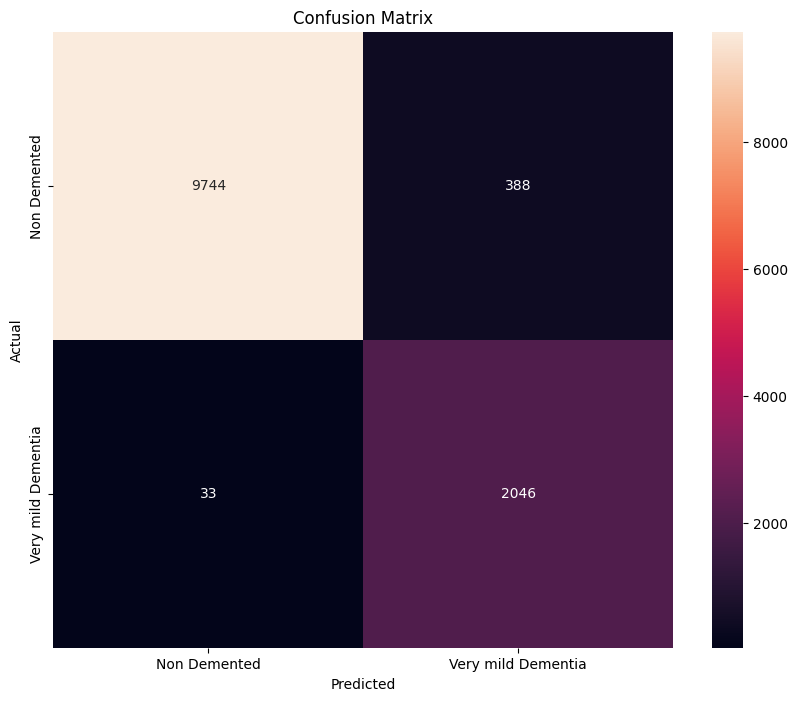

                    precision    recall  f1-score   support

      Non Demented       1.00      0.96      0.98     10132
Very mild Dementia       0.84      0.98      0.91      2079

          accuracy                           0.97     12211
         macro avg       0.92      0.97      0.94     12211
      weighted avg       0.97      0.97      0.97     12211



In [3]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

y_true, y_pred = [], []
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Conclusion
In conclusion, the convolutional neural network appears to work very well for both identifying different severities of dementia and even identifying between non-demented patients and very mildly demented patients since all classes achieve F1 scores above 0.90. The model classifying different severities performs well however the differences between severities may be verifiable by eye and may not be as useful in a practical scenario as the model classifying between non-demented and very mildly demented patients since it may be more valuable to identify the earlier stages of the illness rather than the later stages. 

The classification between the non-demented and very mildly demented patients may be more useful in a practical scenario, achieving a recall of 0.96 for non-demented patients and 0.98 recall for very mildly demented patients, the 0.84 precision for very mild dementia shows that it may return false positive cases of very mild dementia which may however do less damage in a practical scenario in comparison to a false negative.